In [1]:
import os
import glob
import json
import random
from PIL import Image

def create_character_crops():
    print("Slicing 17 pages into 30,000+ individual character images...")
    
    # Raw Kaggle Input Paths
    json_dir = "/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/annotations"
    img_dir = "/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/images"
    
    # New Output Path for ResNet
    base_out = "/kaggle/working/resnet_character_crops"
    
    json_files = glob.glob(os.path.join(json_dir, "*.json"))
    crop_count, skipped_count = 0, 0
    
    for json_path in json_files:
        base_name = os.path.splitext(os.path.basename(json_path))[0]
        
        img_path = None
        for ext in ['.jpg', '.JPG', '.png', '.jpeg']:
            temp = os.path.join(img_dir, f"{base_name}{ext}")
            if os.path.exists(temp):
                img_path = temp
                break
                
        if not img_path: continue
            
        img = Image.open(img_path).convert('RGB')
        
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        for i, shape in enumerate(data.get('shapes', [])):
            label = shape.get('label')
            points = shape.get('points')
            
            if not label or not points or len(points) < 2:
                skipped_count += 1
                continue
                
            xs = [p[0] for p in points]
            ys = [p[1] for p in points]
            
            # 2-pixel buffer
            x1, y1 = max(0, min(xs) - 2), max(0, min(ys) - 2)
            x2, y2 = min(img.width, max(xs) + 2), min(img.height, max(ys) + 2)
            
            try:
                crop_img = img.crop((x1, y1, x2, y2))
                if crop_img.width < 3 or crop_img.height < 3: continue
            except:
                skipped_count += 1
                continue
                
            split = 'train' if random.random() < 0.85 else 'val'
            out_dir = os.path.join(base_out, split, label)
            os.makedirs(out_dir, exist_ok=True)
            
            crop_path = os.path.join(out_dir, f"{base_name}_{i}.jpg")
            crop_img.save(crop_path)
            crop_count += 1
            
    print(f"\n✅ SUCCESS! Extracted: {crop_count} crops. Ready at: {base_out}")

create_character_crops()

Slicing 17 pages into 30,000+ individual character images...

✅ SUCCESS! Extracted: 6679 crops. Ready at: /kaggle/working/resnet_character_crops


# EDA

Loaded 002.jpg. Found 626 characters on this page.


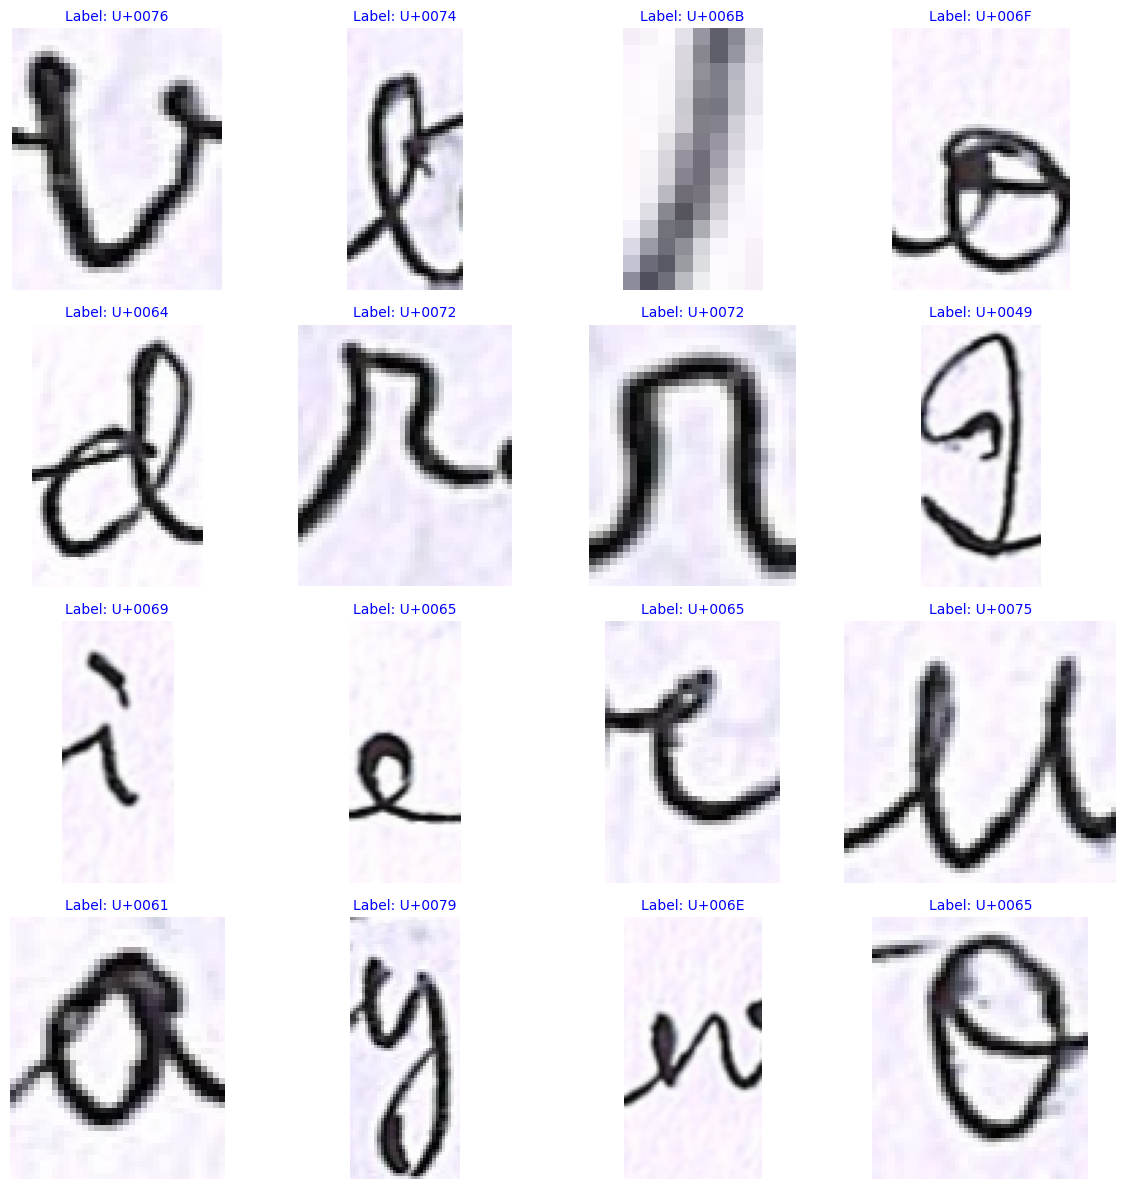

In [2]:
import os
import json
import cv2
import random
import matplotlib.pyplot as plt

# Define your data directories
TRAIN_IMG_DIR = "/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/images"
TRAIN_ANN_DIR = "/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/annotations"

# 1. Grab all available annotation files
ann_files = [f for f in os.listdir(TRAIN_ANN_DIR) if f.endswith('.json')]

if not ann_files:
    print("No annotation files found! Check your TRAIN_ANN_DIR path.")
else:
    # Pick a random JSON file to look at
    selected_json = random.choice(ann_files)
    selected_img = selected_json.replace('.json', '.jpg')
    
    img_path = os.path.join(TRAIN_IMG_DIR, selected_img)
    ann_path = os.path.join(TRAIN_ANN_DIR, selected_json)
    
    # 2. Load the image and its JSON file
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for correct Matplotlib colors
    
    with open(ann_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    shapes = data.get('shapes', [])
    print(f"Loaded {selected_img}. Found {len(shapes)} characters on this page.")
    
    # 3. Randomly sample up to 16 characters to display in a 4x4 grid
    num_to_display = min(16, len(shapes))
    sampled_shapes = random.sample(shapes, num_to_display)
    
    # Create the Matplotlib figure
    plt.figure(figsize=(12, 12))
    
    for i, shape in enumerate(sampled_shapes):
        label = shape.get('label', 'Unknown')
        points = shape.get('points', [])
        
        if len(points) == 2:
            # Unpack and sort coordinates to prevent inverse clipping
            x1, x2 = int(min(points[0][0], points[1][0])), int(max(points[0][0], points[1][0]))
            y1, y2 = int(min(points[0][1], points[1][1])), int(max(points[0][1], points[1][1]))
            
            # Add a small padding buffer (like your 2-stage script does)
            padding = 2
            y1_pad = max(0, y1 - padding)
            y2_pad = min(img.shape[0], y2 + padding)
            x1_pad = max(0, x1 - padding)
            x2_pad = min(img.shape[1], x2 + padding)
            
            # Crop the character out of the full canvas
            crop = img[y1_pad:y2_pad, x1_pad:x2_pad]
            
            # Plot inside a 4x4 grid layout
            plt.subplot(4, 4, i + 1)
            plt.imshow(crop)
            plt.title(f"Label: {label}", fontsize=10, color='blue')
            plt.axis('off') # Hide pixel grid lines for clean viewing
            
    plt.tight_layout()
    plt.show()

In [3]:
import os
import shutil
import json
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split

# --- 1. THE DATA MERGE FIX ---
print("Fixing scrambled dataset folders...")
train_dir = '/kaggle/working/resnet_character_crops/train'
val_dir = '/kaggle/working/resnet_character_crops/val'

# Move all validation images back into the train folder to create one master set
if os.path.exists(val_dir):
    for cls_folder in os.listdir(val_dir):
        src_folder = os.path.join(val_dir, cls_folder)
        dst_folder = os.path.join(train_dir, cls_folder)
        os.makedirs(dst_folder, exist_ok=True)
        for f in os.listdir(src_folder):
            shutil.move(os.path.join(src_folder, f), os.path.join(dst_folder, f))
    print("Data merged successfully into a single master folder!")

# --- 2. TRAIN WITH PERFECT LABELS ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Restarting Training on: {device}")

# Standardize to 64x64
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load everything into ONE dataset so the dictionary is locked in flawlessly
master_dataset = datasets.ImageFolder(train_dir, transform=transform)
num_classes = len(master_dataset.classes)
print(f"Locked in exactly {num_classes} unique Unicode classes!")

# Save the master dictionary for inference! (CRITICAL)
class_mapping = {i: c for c, i in master_dataset.class_to_idx.items()}
with open('/kaggle/working/resnet_class_mapping.json', 'w') as f:
    json.dump(class_mapping, f)

# Split 85/15 safely inside PyTorch
train_size = int(0.85 * len(master_dataset))
val_size = len(master_dataset) - train_size
train_data, val_data = random_split(master_dataset, [train_size, val_size])

dataloaders = {
    'train': DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2),
    'val': DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2)
}
dataset_sizes = {'train': train_size, 'val': val_size}

# Load Model
model = models.resnet34(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10  
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    
    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase.capitalize()} Acc: {epoch_acc:.4f}')

        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/kaggle/working/resnet_character_master.pth')
print(f"\n✅ Brain saved! Real Val Acc: {best_acc:.4f}")

Fixing scrambled dataset folders...
Data merged successfully into a single master folder!
Restarting Training on: cuda:0
Locked in exactly 167 unique Unicode classes!
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 215MB/s]


Epoch 1/10
Train Acc: 0.5138
Val Acc: 0.6138
Epoch 2/10
Train Acc: 0.6761
Val Acc: 0.6487
Epoch 3/10
Train Acc: 0.7277
Val Acc: 0.6886
Epoch 4/10
Train Acc: 0.7733
Val Acc: 0.6747
Epoch 5/10
Train Acc: 0.8039
Val Acc: 0.6507
Epoch 6/10
Train Acc: 0.8283
Val Acc: 0.7016
Epoch 7/10
Train Acc: 0.8508
Val Acc: 0.6667
Epoch 8/10
Train Acc: 0.8475
Val Acc: 0.6577
Epoch 9/10
Train Acc: 0.8675
Val Acc: 0.7006
Epoch 10/10
Train Acc: 0.8878
Val Acc: 0.6786

✅ Brain saved! Real Val Acc: 0.7016


In [4]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 107.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 

In [5]:
import ultralytics
import torch
print(f"Ultralytics: {ultralytics.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.58
CUDA Available: True


In [6]:
import os
import glob
import json
import shutil
import random
from PIL import Image

def build_class_agnostic_yolo():
    print("Building fresh Class-Agnostic YOLO Dataset (1 Class)...")
    
    json_dir = "/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/annotations"
    img_dir = "/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/images"
    base_out = "/kaggle/working/yolo_agnostic"
    
    for folder in ['images/train', 'images/val', 'labels/train', 'labels/val']:
        os.makedirs(os.path.join(base_out, folder), exist_ok=True)
        
    json_files = glob.glob(os.path.join(json_dir, "*.json"))
    random.shuffle(json_files) # Shuffle for random split
    
    for i, json_path in enumerate(json_files):
        base_name = os.path.splitext(os.path.basename(json_path))[0]
        
        img_path = None
        for ext in ['.jpg', '.JPG', '.png', '.jpeg']:
            temp = os.path.join(img_dir, f"{base_name}{ext}")
            if os.path.exists(temp):
                img_path = temp
                break
        if not img_path: continue
            
        img = Image.open(img_path)
        img_w, img_h = img.width, img.height
        
        split = 'train' if i < int(len(json_files) * 0.85) else 'val'
        
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        yolo_lines = []
        for shape in data.get('shapes', []):
            points = shape.get('points')
            if not points or len(points) < 2: continue
                
            xs, ys = [p[0] for p in points], [p[1] for p in points]
            xmin, xmax = min(xs), max(xs)
            ymin, ymax = min(ys), max(ys)
            
            # Convert to YOLO format (x_center, y_center, width, height) mapped 0-1
            xc = ((xmin + xmax) / 2.0) / img_w
            yc = ((ymin + ymax) / 2.0) / img_h
            w = (xmax - xmin) / img_w
            h = (ymax - ymin) / img_h
            
            # FORCE CLASS TO 0 (Class-Agnostic)
            yolo_lines.append(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
            
        if yolo_lines:
            shutil.copy(img_path, os.path.join(base_out, 'images', split, os.path.basename(img_path)))
            with open(os.path.join(base_out, 'labels', split, f"{base_name}.txt"), 'w') as f:
                f.writelines(yolo_lines)
                
    # Generate the YAML file
    yaml_path = os.path.join(base_out, 'dataset.yaml')
    with open(yaml_path, 'w') as f:
        f.write(f"train: {base_out}/images/train\nval: {base_out}/images/val\nnc: 1\nnames: ['character']")
        
    print(f"✅ SUCCESS! Dataset and YAML built at: {yaml_path}")

build_class_agnostic_yolo()

Building fresh Class-Agnostic YOLO Dataset (1 Class)...
✅ SUCCESS! Dataset and YAML built at: /kaggle/working/yolo_agnostic/dataset.yaml


In [7]:
from ultralytics import YOLO

# Load the fast, efficient Nano model
model = YOLO('yolov8n.pt') 

results = model.train(
    data='/kaggle/working/yolo_agnostic/dataset.yaml',
    epochs=100,       
    imgsz=1280,
    batch=4,          
    project='/kaggle/working/runs',
    name='comsys_yolo_agnostic',
    # Since it's only finding boxes, these augmentations help it find faint ink
    scale=0.5,
    mosaic=1.0
)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_agnostic/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=comsys_yolo_agnostic, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

# Check

🚀 Loading Pipeline...

🖼️ Testing Image: /kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/test/images/001.jpg

🧠 ResNet is processing 300 character crops...


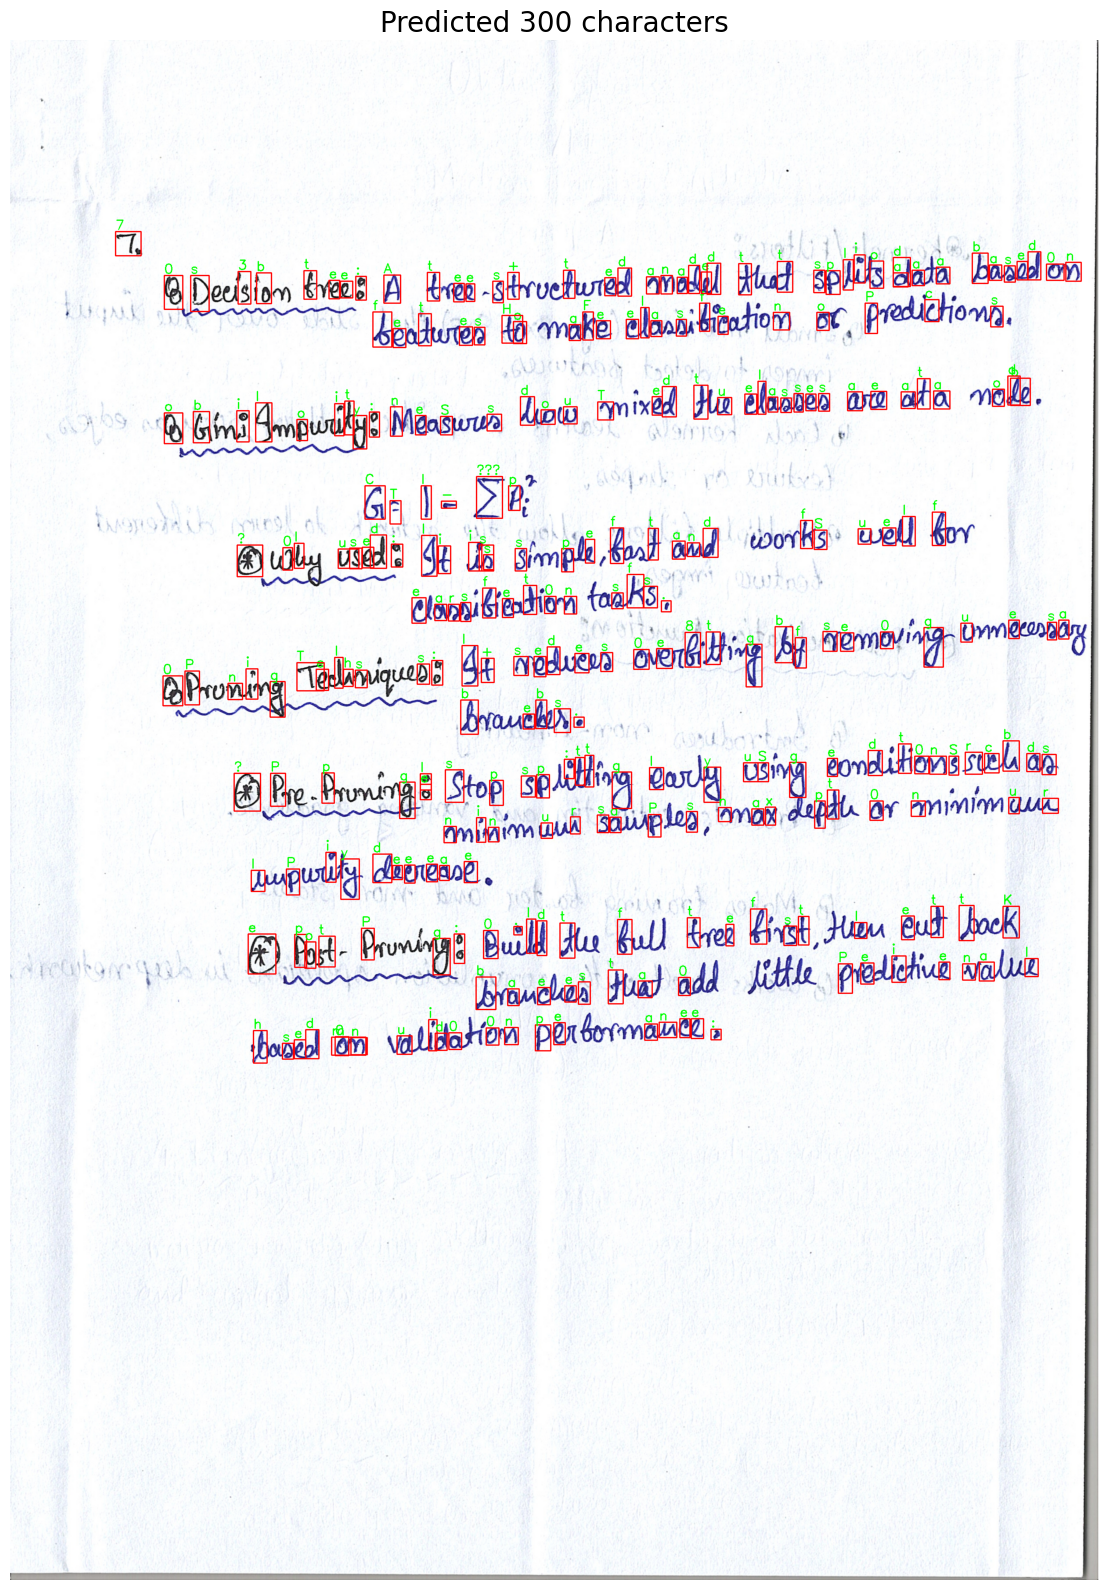

In [8]:
import cv2
import json
import torch
import random
import glob
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from ultralytics import YOLO
import torch.nn as nn

def visualize_full_pipeline_with_text():
    print("🚀 Loading Pipeline...")
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # 1. Load the ResNet Dictionary & Brain
    with open('/kaggle/working/resnet_class_mapping.json', 'r') as f:
        class_mapping = {int(k): v for k, v in json.load(f).items()}
    
    resnet_model = models.resnet34(weights=None)
    resnet_model.fc = nn.Linear(resnet_model.fc.in_features, len(class_mapping))
    resnet_model.load_state_dict(torch.load('/kaggle/working/resnet_character_master.pth'))
    resnet_model = resnet_model.to(device)
    resnet_model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 2. Load YOLO
    yolo_paths = glob.glob('/kaggle/working/runs/**/comsys_yolo_agnostic/weights/best.pt', recursive=True)
    if not yolo_paths:
        yolo_paths = glob.glob('/kaggle/working/runs/**/*.pt', recursive=True)
    yolo = YOLO(yolo_paths[0])
    
    # 3. Choose the image
    # To use a specific image, replace the next two lines with: img_path = '/your/exact/path.jpg'
    test_images = glob.glob('/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/test/images/*.*')
    img_path = random.choice(test_images)
    print(f"\n🖼️ Testing Image: {img_path}")
    
    pil_img = Image.open(img_path).convert('RGB')
    cv_img = cv2.imread(img_path)
    cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
    
    # Run YOLO
    results = yolo(img_path, conf=0.10, iou=0.45, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    print(f"\n🧠 ResNet is processing {len(boxes)} character crops...")
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        # Crop and predict with ResNet
        crop = pil_img.crop((max(0, x1-2), max(0, y1-2), min(pil_img.width, x2+2), min(pil_img.height, y2+2)))
        if crop.width < 3 or crop.height < 3: continue
            
        tensor_crop = transform(crop).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = resnet_model(tensor_crop)
            _, pred = torch.max(output, 1)
            unicode_val = class_mapping[pred.item()] # e.g., "U+0041"
            
            # Convert "U+XXXX" to an actual character
            try:
                hex_str = unicode_val.replace('U+', '').replace('u+', '')
                actual_char = chr(int(hex_str, 16))
            except:
                actual_char = "?" # Fallback if parsing fails
        
        # Draw the bounding box (Red)
        cv2.rectangle(cv_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        
        # Draw the predicted character (Green, slightly above the box)
        # Parameters: image, text, bottom-left-corner, font, scale, color(RGB), thickness
        cv2.putText(cv_img, actual_char, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
    # Display the final image
    plt.figure(figsize=(25, 20))
    plt.imshow(cv_img)
    plt.axis('off')
    plt.title(f"Predicted {len(boxes)} characters", fontsize=20)
    plt.show()

# Run it!
visualize_full_pipeline_with_text()

In [9]:
import os
import glob
import json
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from torchvision import transforms, models
from ultralytics import YOLO

def generate_two_stage_submission():
    print("🚀 Initializing Two-Stage Enterprise Pipeline...")
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # ---------------------------------------------------------
    # 1. LOAD THE RESNET BRAIN & DICTIONARY
    # ---------------------------------------------------------
    with open('/kaggle/working/resnet_class_mapping.json', 'r') as f:
        class_mapping = {int(k): v for k, v in json.load(f).items()}
        
    num_classes = len(class_mapping)
    
    resnet_model = models.resnet34(weights=None)
    resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
    resnet_model.load_state_dict(torch.load('/kaggle/working/resnet_character_master.pth'))
    resnet_model = resnet_model.to(device)
    resnet_model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # ---------------------------------------------------------
    # 2. LOAD THE YOLO EYE (Class-Agnostic)
    # ---------------------------------------------------------
    yolo_paths = glob.glob('/kaggle/working/runs/**/comsys_yolo_agnostic/weights/best.pt', recursive=True)
    if not yolo_paths:
        yolo_paths = glob.glob('/kaggle/working/runs/**/*.pt', recursive=True)
        
    print(f"👁️ Loaded YOLO from: {yolo_paths[0]}")
    yolo_model = YOLO(yolo_paths[0])
    
    # ---------------------------------------------------------
    # 3. RUN INFERENCE ON TEST SET
    # ---------------------------------------------------------
    test_dir = '/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/test/images'
    test_images = glob.glob(os.path.join(test_dir, '*.*'))
    
    submission_data = []
    print(f"Starting batched inference on {len(test_images)} test images...\n")
    
    for img_path in test_images:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        pil_img = Image.open(img_path).convert('RGB')
        
        # --- A. YOLO Finds the Boxes ---
        results = yolo_model(img_path, conf=0.10, iou=0.45, augment=True, max_det=1500, verbose=False) 
        boxes = results[0].boxes.xyxy.cpu().numpy()
        
        crop_tensors = []
        valid_boxes = []
        
        # --- B. Physically Crop Every Box ---
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            
            x1, y1 = max(0, x1 - 2), max(0, y1 - 2)
            x2, y2 = min(pil_img.width, x2 + 2), min(pil_img.height, y2 + 2)
            
            if x2 - x1 < 3 or y2 - y1 < 3:
                continue
                
            crop = pil_img.crop((x1, y1, x2, y2))
            crop_tensors.append(transform(crop))
            valid_boxes.append([float(x1), float(y1), float(x2), float(y2)])
            
        character_predictions = []
        bengali_votes = 0
        english_votes = 0
        
        # --- C. GPU Batched Inference (ResNet) ---
        if crop_tensors:
            batch_tensor = torch.stack(crop_tensors).to(device)
            
            with torch.no_grad():
                outputs = resnet_model(batch_tensor)
                _, preds = torch.max(outputs, 1)
                
            # --- D. Map Predictions to JSON ---
            for i, pred_idx in enumerate(preds.cpu().numpy()):
                unicode_val = class_mapping[pred_idx]
                
                if unicode_val.startswith('U+09'):
                    bengali_votes += 1
                else:
                    english_votes += 1
                    
                char_dict = {
                    "unicode_value": unicode_val,
                    "bbox": valid_boxes[i]
                }
                character_predictions.append(json.dumps(char_dict, separators=(',', ':')))
                
        # --- E. Format Hackathon Output ---
        script_id = 1 if bengali_votes > english_votes else 0
        
        if len(character_predictions) > 0:
            chars_joined = ",".join(character_predictions)
            final_pred_string = f'["script":{script_id},{chars_joined}]'
        else:
            final_pred_string = f'["script":{script_id}]'
            
        print(f"📄 Page {base_name:3} | Script: {script_id} | Characters Detected: {len(valid_boxes)}")
            
        submission_data.append({
            "page_id": base_name,
            "predictions": final_pred_string
        })
        
    # ---------------------------------------------------------
    # 4. SAVE TO CSV
    # ---------------------------------------------------------
    df = pd.DataFrame(submission_data)
    df = df.sort_values(by="page_id") 
    
    # EXACT KAGGLE FILENAME
    submission_path = '/kaggle/working/submission.csv'
    df.to_csv(submission_path, index=False)
    
    print(f"\n🎯 Pipeline complete! File saved to: {submission_path}")

# Execute!
generate_two_stage_submission()

🚀 Initializing Two-Stage Enterprise Pipeline...
👁️ Loaded YOLO from: /kaggle/working/runs/comsys_yolo_agnostic/weights/best.pt
Starting batched inference on 6 test images...

📄 Page 102 | Script: 1 | Characters Detected: 226
📄 Page 101 | Script: 1 | Characters Detected: 198
📄 Page 010 | Script: 0 | Characters Detected: 926
📄 Page 001 | Script: 0 | Characters Detected: 801
📄 Page 005 | Script: 0 | Characters Detected: 805
📄 Page 019 | Script: 0 | Characters Detected: 1500

🎯 Pipeline complete! File saved to: /kaggle/working/submission.csv


# using context

In [10]:
# CELL 1: Local Open-Source Language Model Setup
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Load an ultra-lightweight bilingual model (Excellent for mixed English/Bengali)
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"📥 Loading local correction engine: {model_name}...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

def local_llm_correction_engine(raw_text: str) -> str:
    """Uses the local Qwen model to perform context-aware OCR spelling correction."""
    if not raw_text.strip():
        return ""
        
    messages = [
        {
            "role": "system", 
            "content": "You are a bilingual English/Bengali OCR post-processing corrector. Fix optical character confusion errors (e.g., 'H1LO' -> 'HELLO', 'l' -> 'I'). Respond ONLY with the clean corrected string. Do not include commentary."
        },
        {"role": "user", "content": f"Correct this raw OCR text: {raw_text}"}
    ]
    
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(llm_model.device)
    
    with torch.no_grad():
        generated_ids = llm_model.generate(
            **model_inputs,
            max_new_tokens=128,
            temperature=0.1,
            do_sample=False
        )
    
    # Strip prompt tokens from generation output
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

print("✅ Local LLM Text Correction Engine Ready.")

📥 Loading local correction engine: Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Local LLM Text Correction Engine Ready.


In [11]:
# CELL 2: Core Sorting & Dynamic Sequence Alignment Mechanics
import numpy as np
import difflib

def sort_and_cluster_boxes(boxes, vertical_tolerance_ratio=0.55, space_ratio=0.5):
    """Clusters scattered bounding boxes into rows (top-to-bottom) and columns (left-to-right)."""
    if len(boxes) == 0: return []
    
    bboxes = []
    heights = []
    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = map(float, box[:4])
        heights.append(y2 - y1)
        bboxes.append({'box': [int(x1), int(y1), int(x2), int(y2)], 'cx': (x1 + x2) / 2.0, 'cy': (y1 + y2) / 2.0, 'original_idx': idx})
        
    median_h = np.median(heights)
    bboxes = sorted(bboxes, key=lambda x: x['cx'])
    lines = []
    
    for b in bboxes:
        best_line = None
        best_y_diff = float('inf')
        for line in lines:
            y_diff = abs(b['cy'] - line[-1]['cy'])
            if y_diff < (median_h * vertical_tolerance_ratio) and y_diff < best_y_diff:
                best_y_diff = y_diff
                best_line = line
        if best_line is not None: best_line.append(b)
        else: lines.append([b])
            
    lines.sort(key=lambda l: np.mean([b['cy'] for b in l]))
    final_sorted_boxes = []
    
    for line_idx, line in enumerate(lines):
        line = sorted(line, key=lambda x: x['cx'])
        for i, b in enumerate(line):
            b['line_idx'] = line_idx
            b['preceded_by_space'] = (b['box'][0] - line[i-1]['box'][2] > median_h * space_ratio) if i > 0 else False
            final_sorted_boxes.append(b)
    return final_sorted_boxes

def dynamic_sequence_alignment(raw_string, raw_box_map, corrected_string, width, height):
    """Maps the modified target string back onto the spatial character coordinates via sequence matching."""
    matcher = difflib.SequenceMatcher(None, raw_string, corrected_string)
    corrected_boxes = [None] * len(corrected_string)
    
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            for offset in range(i2 - i1):
                if raw_box_map[i1 + offset] is not None:
                    corrected_boxes[j1 + offset] = raw_box_map[i1 + offset]['box']
        elif tag in ('replace', 'insert'):
            left_box = next((raw_box_map[x]['box'] for x in range(i1 - 1, -1, -1) if raw_box_map[x]), None)
            right_box = next((raw_box_map[x]['box'] for x in range(i2, len(raw_box_map)) if raw_box_map[x]), None)
            internal = [raw_box_map[x]['box'] for x in range(i1, i2) if raw_box_map[x]]
            
            x_min = min(b[0] for b in internal) if internal else (left_box[2] if left_box else 50)
            x_max = max(b[2] for b in internal) if internal else (right_box[0] if right_box else width - 50)
            y_min = min(b[1] for b in internal) if internal else (left_box[1] if left_box else 50)
            y_max = max(b[3] for b in internal) if internal else (left_box[3] if left_box else 150)
            
            num_chars = j2 - j1
            if num_chars > 0:
                char_w = max(1, x_max - x_min) / num_chars
                for offset in range(num_chars):
                    if corrected_string[j1 + offset] != ' ':
                        corrected_boxes[j1 + offset] = [int(x_min + offset * char_w), int(y_min), int(x_min + (offset + 1) * char_w), int(y_max)]
    return corrected_boxes

🧠 Loading ResNet-34 classification engine...
👁️ Loading class-agnostic YOLO detector...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


📋 Raw Structural Sequence Generated: P c s c PSS n c r du ag g Po ne neares ce c o d o ceo ee d : Caecc eaege of aee e e dc a S eac c Ed e e e c so sa f gUabo e h o S s n u)? e e ee e hi e f n e e a e eo e S ne ed / /h e oeo n e ib ehnee ehed )h n/ a son a dhan a e h ca( ( no cl ege edPelu ac as 2 t c en is a c de edgin e d e asa h a2s f h ?( a (o= af a )o oc Pf a C oa s = oReee b e e in cn n be ees ot aae T eesoo i eades ne e e a h adP y gP e a eo s e a o S C e e ceuo sl na f S 2 anc c a o e e 2e p e e s
🤖 Routing text sequence through local LLM correction layer...
✨ Context-Aware Corrected Text Output: Please provide the original text for correction.


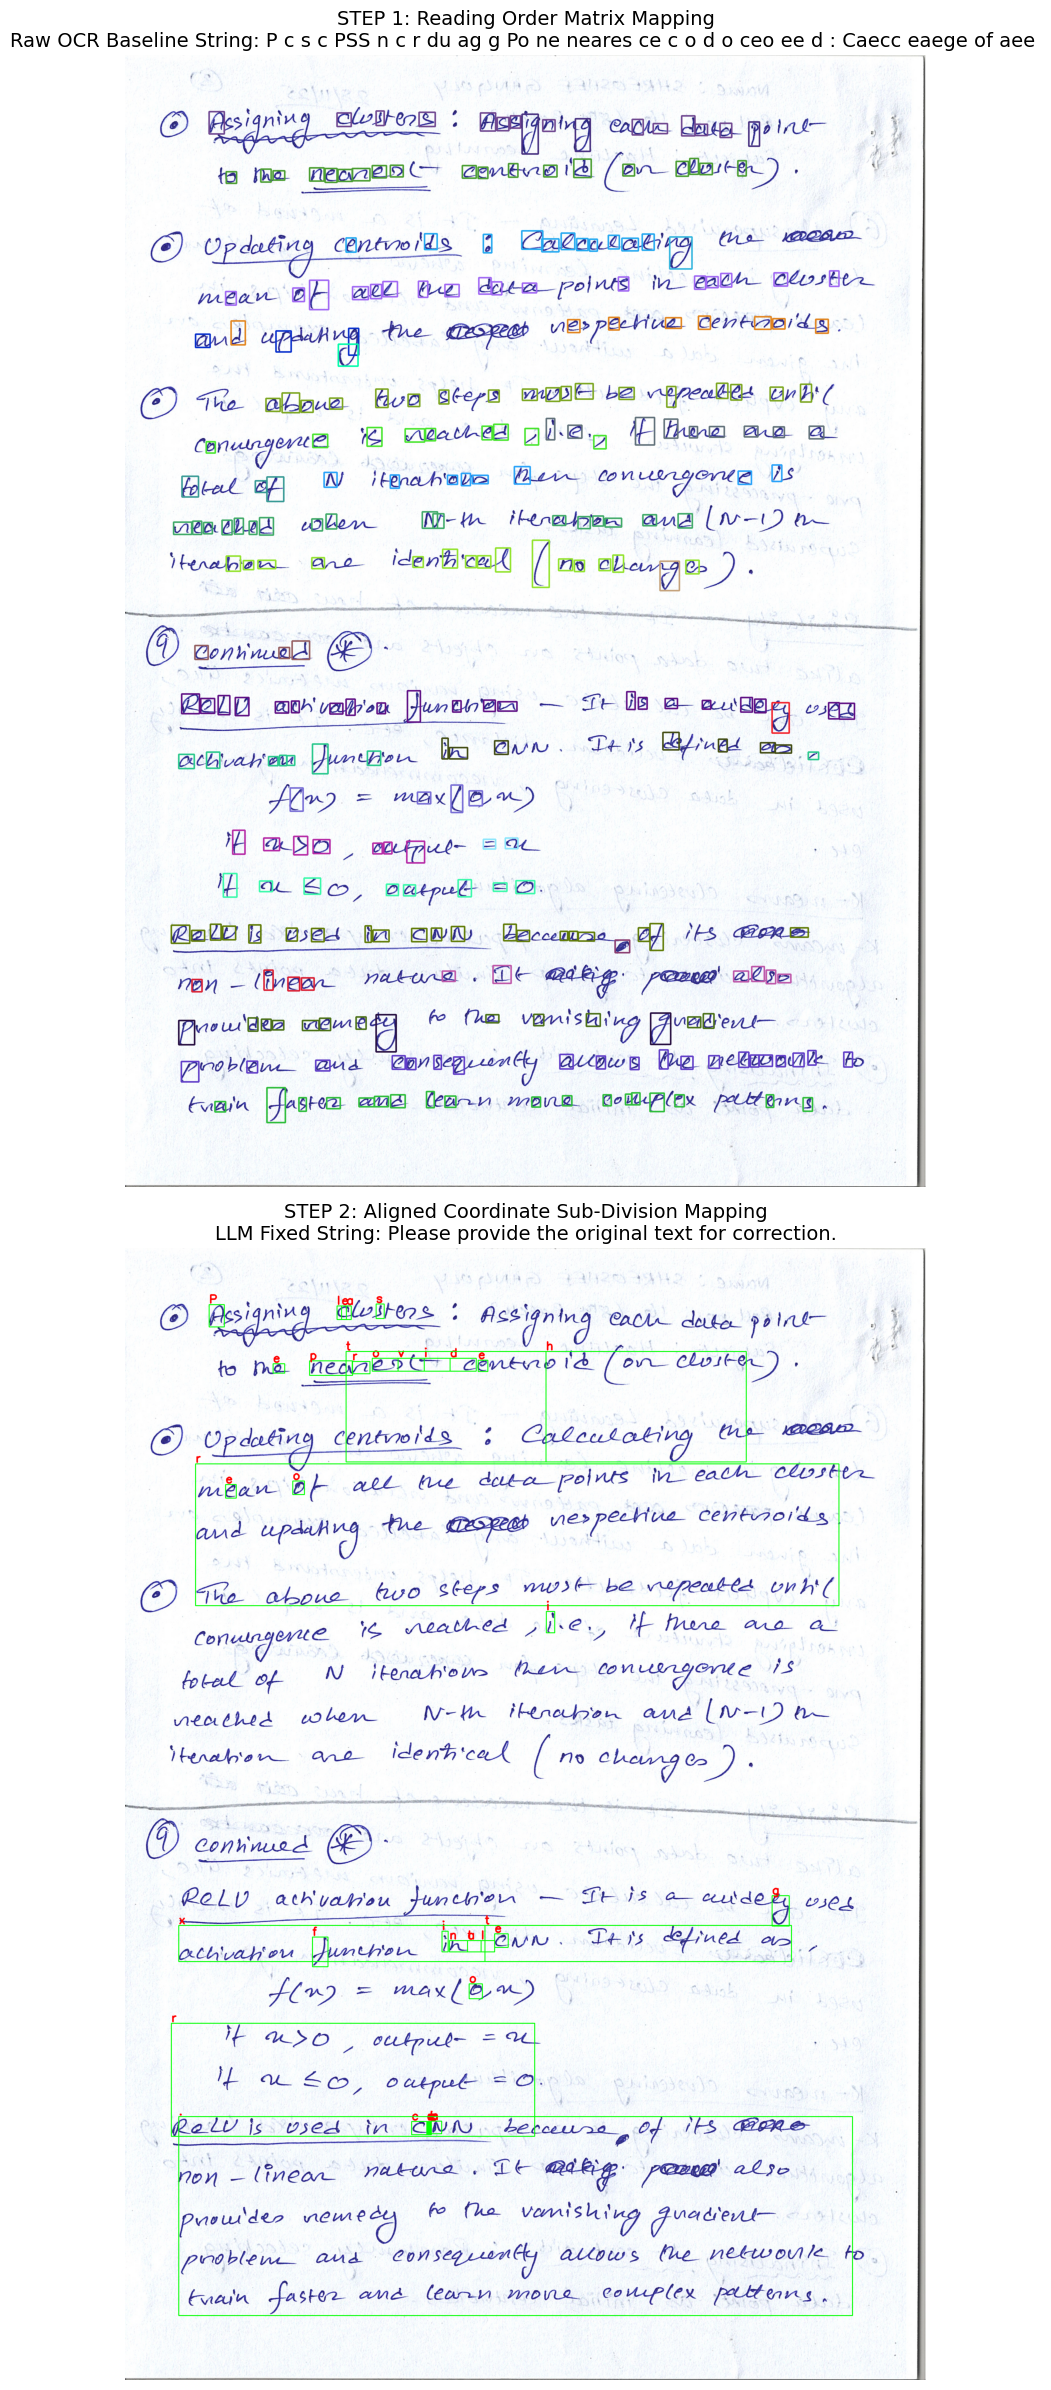

In [12]:
# CELL 3: Execution Pipeline and Step-by-Step Visualizations
import os
import glob
import json
import random
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from ultralytics import YOLO

def run_stepwise_eda_pipeline():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # 1. Load Class Mapping
    with open('/kaggle/working/resnet_class_mapping.json', 'r') as f:
        class_mapping = {int(k): v for k, v in json.load(f).items()}
        
    # 2. Re-initialize and load ResNet-34 inside cell scope to avoid NameErrors
    print("🧠 Loading ResNet-34 classification engine...")
    resnet_model = models.resnet34(weights=None)
    resnet_model.fc = nn.Linear(resnet_model.fc.in_features, len(class_mapping))
    resnet_model.load_state_dict(torch.load('/kaggle/working/resnet_character_master.pth', map_location=device))
    resnet_model = resnet_model.to(device).eval()
    
    # Define exact input tensor preprocessing pipeline used during training
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 3. Automatically locate YOLO checkpoints
    print("👁️ Loading class-agnostic YOLO detector...")
    yolo_candidates = glob.glob('/kaggle/working/runs/**/*.pt', recursive=True)
    if not yolo_candidates:
        raise FileNotFoundError("Could not find any YOLO weights (.pt) in /kaggle/working/runs/")
    yolo = YOLO(yolo_candidates[0])
    
    # 4. Pull a random verification target from the test partition
    test_images = glob.glob('/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/test/images/*.*')
    img_path = random.choice(test_images)
    pil_img = Image.open(img_path).convert('RGB')
    cv_img_raw = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    
    # 5. Detect character boundaries & calculate reading-order layouts
    results = yolo(img_path, conf=0.10, iou=0.45, verbose=False)
    sorted_boxes = sort_and_cluster_boxes(results[0].boxes.xyxy.cpu().numpy())
    
    # 6. Step-by-Step Character Feature Extraction
    raw_chars, raw_box_map = [], []
    for b in sorted_boxes:
        if b['preceded_by_space']:
            raw_chars.append(' ')
            raw_box_map.append(None)
        
        x1, y1, x2, y2 = b['box']
        crop = pil_img.crop((max(0, x1-2), max(0, y1-2), min(pil_img.width, x2+2), min(pil_img.height, y2+2)))
        if crop.width < 3 or crop.height < 3: 
            continue
            
        tensor_crop = transform(crop).unsqueeze(0).to(device)
        with torch.no_grad():
            output = resnet_model(tensor_crop)
            _, pred = torch.max(output, 1)
        
        try:
            char = chr(int(class_mapping[pred.item()].replace('U+', ''), 16))
        except:
            char = "?"
        
        b['raw_char'] = char
        raw_chars.append(char)
        raw_box_map.append(b)
        
    raw_text = "".join(raw_chars)
    print(f"📋 Raw Structural Sequence Generated: {raw_text}")
    
    # 7. Post-Processing Context Correction Layer (Calls Cell 1)
    print("🤖 Routing text sequence through local LLM correction layer...")
    corrected_text = local_llm_correction_engine(raw_text)
    print(f"✨ Context-Aware Corrected Text Output: {corrected_text}")
    
    # 8. Dynamic Geometric Coordinate Anchor Mapping (Calls Cell 2)
    final_aligned_boxes = dynamic_sequence_alignment(raw_text, raw_box_map, corrected_text, pil_img.width, pil_img.height)
    
    # =========================================================================
    # VISUAL EDA GENERATION WINDOWS
    # =========================================================================
    fig, axes = plt.subplots(2, 1, figsize=(20, 24))
    
    # Canvas Frame 1: Text Line Segmentation Paths
    img_lines = cv_img_raw.copy()
    line_colors = [(random.randint(0,255), random.randint(0,255), random.randint(0,255)) for _ in range(50)]
    for b in sorted_boxes:
        x1, y1, x2, y2 = b['box']
        cv2.rectangle(img_lines, (x1, y1), (x2, y2), line_colors[b['line_idx'] % 50], 3)
    axes[0].imshow(img_lines)
    axes[0].set_title(f"STEP 1: Reading Order Matrix Mapping\nRaw OCR Baseline String: {raw_text[:80]}", fontsize=14)
    axes[0].axis('off')
    
    # Canvas Frame 2: Back-Propagated Character Assignments
    img_aligned = cv_img_raw.copy()
    for idx, char in enumerate(corrected_text):
        box = final_aligned_boxes[idx]
        if box is not None:
            cv2.rectangle(img_aligned, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
            cv2.putText(img_aligned, char, (box[0], box[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
    axes[1].imshow(img_aligned)
    axes[1].set_title(f"STEP 2: Aligned Coordinate Sub-Division Mapping\nLLM Fixed String: {corrected_text[:80]}", fontsize=14)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the updated self-contained execution pipeline loop
run_stepwise_eda_pipeline()